# Using BHJet to study multi-wavelength observations of jetted systems 

This will first start out by producing radiation from a single region, then we will move onto considering emission from many regions. We'll compare this first with observations of M87, and attempt to reproduce the SED.

In [54]:
from pathlib import Path
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from bhjet import BHJet, BLJet, RadiationZone

def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'tutorials' / 'tutorial_data').is_dir():
            return candidate
    raise FileNotFoundError('Open this notebook from a complete BHJet checkout.')


## 1. Choose the source and load the (provided) observations

For a new source, change `SOURCE_NAME` and `SOURCE_DIRECTORY` below. The data lives in `tutorials/tutorial_data/`, and this notebook expects a file named `<directory>/<directory>_dnde.csv`. The distance, redshift, viewing angle, and black-hole mass must also be updated. 

In [55]:
# --- Source settings: change these all at once when adding a new source. ---
SOURCE_NAME = 'NGC 4261'
SOURCE_DIRECTORY = 'ngc4261'
DISTANCE_KPC = 29400 
REDSHIFT = 0.007465
VIEWING_ANGLE_DEG = 66.0
BLACK_HOLE_MASS_SOLAR = 5e8

ERG_TO_EV = 6.242e11
EV_TO_ERG = 1.0 / ERG_TO_EV

repository_root = find_repository_root()
data_directory = repository_root / 'tutorials' / 'tutorial_data' / SOURCE_DIRECTORY
data_file = data_directory / f'{SOURCE_DIRECTORY}_dnde.csv'

if not data_file.is_file():
    raise FileNotFoundError(f'No SED file found for {SOURCE_NAME}: {data_file}')

print(f'Using {SOURCE_NAME}')
print(f'Data directory: {data_directory}')

Using NGC 4261
Data directory: /Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet/tutorials/tutorial_data/ngc4261


## 2. Load and inspect the source SED

The table holds photon energy, differential photon flux, and its uncertainty. Astropy helps to keep the units explicit as we load and convert it to $E^2dN/dE$. (Not necessary for you to do anything with the units here, but here's [an overview](https://learn.astropy.org/tutorials/quantities.html) if you would like)

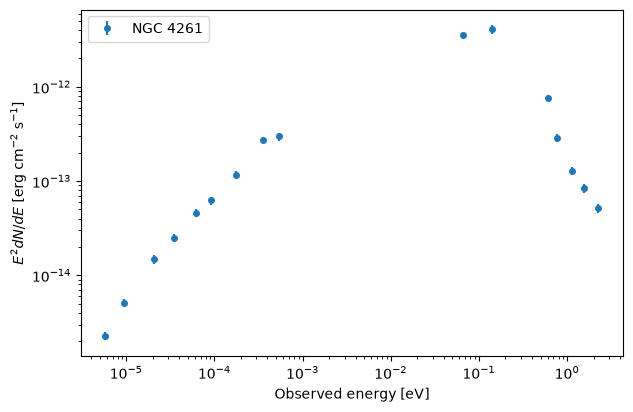

In [56]:
data = Table.read(data_file, format='ascii.csv', delimiter=' ')
data['e_ref'].unit = u.eV
data['dnde'].unit = u.Unit('cm-2 s-1 eV-1')
data['dnde_err'].unit = u.Unit('cm-2 s-1 eV-1')

data_energy = data['e_ref'].quantity

data_sed = (
    data_energy.to(u.erg)**2 * data['dnde'].quantity.to('cm-2 s-1 erg-1')
).to('erg cm-2 s-1')

data_sed_error = (
    data_energy.to(u.erg)**2 * data['dnde_err'].quantity.to('cm-2 s-1 erg-1')
).to('erg cm-2 s-1')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(data_energy.to_value(u.eV), data_sed.value, yerr=data_sed_error.value,
            fmt='o', ms=4, label=SOURCE_NAME)
ax.set(xscale='log', yscale='log', xlabel='Observed energy [eV]',
       ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.legend();

## 3. A single emission zone

In [57]:
# We first need an energy grid over which to calculate the model: 
energy_eV = np.geomspace(1e-7, 1e11, 200)

#Then we set the parameters for our "blob": 
single_zone = RadiationZone(
    distance=DISTANCE_KPC, redshift=REDSHIFT, theta_obs=VIEWING_ANGLE_DEG,
    magnetic_field=0.2, #uniform magnetic field throughout the entire blob
    radius=1e16, #size of the blob (in cm)
    height=1e16, #height of the blob (in cm)
    geometry='sphere',
    bulk_momentum=2.0, #Lorentz factor of the blob
    electron_number_density=1e3, #how many electrons do we want to put in 
    electron_temperature=900, #in keV 
    fraction_nonthermal_electrons=0.1, #how many particles do you want to accelerate?
    factor_break_electrons=0.1, 
    factor_max_energy_electrons=1e-7, #maximum energy of the electrons 
    index_injected_electrons=1.8,
    include_counterjet=True,
    compton_threshold=1e-5,
)
# Now, calculate: 
single_zone.compute_particles()
single_zone.compute_radiation((energy_eV * EV_TO_ERG).tolist())

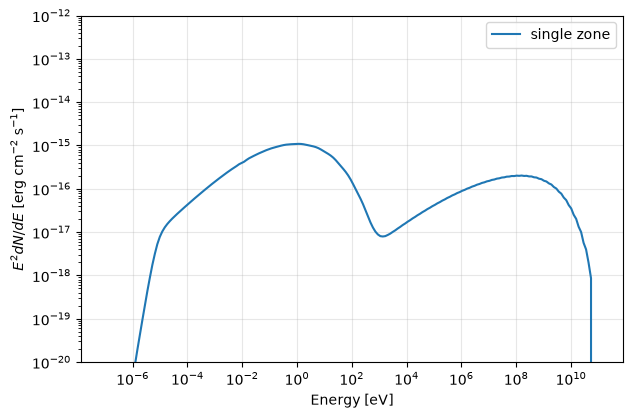

In [58]:
# Plotting our computed spectrum: 
single_zone_energy_eV = np.asarray(single_zone.get_observed_photon_energy_grid_total(), dtype=float) * ERG_TO_EV
single_zone_sed = (single_zone_energy_eV * EV_TO_ERG
    * np.asarray(single_zone.get_observed_photon_flux_total(), dtype=float)
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(single_zone_energy_eV, single_zone_sed, label='single zone')
ax.set(xlabel='Energy [eV]', ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.grid(alpha=0.3)
ax.legend()
plt.ylim(1e-20, 1e-12)
plt.show()

### 3a. Now, let's compare it to observations. 

Change a few of the parameters, re-run the code and try to get it to match the observations. 

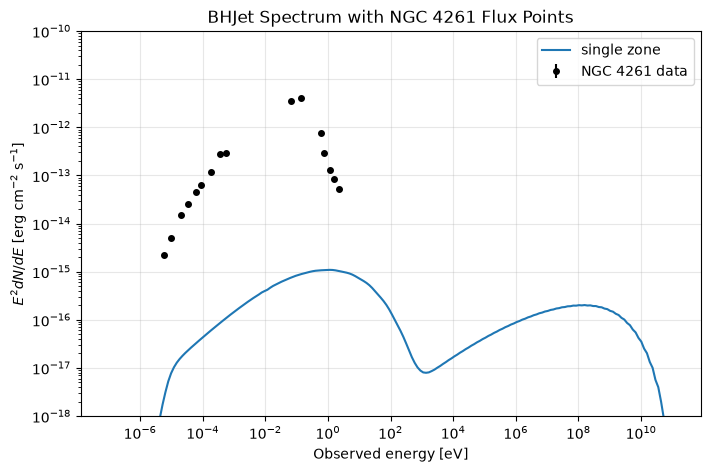

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_energy.to_value(u.eV), data_sed.value, yerr=data_sed_error.value, fmt='o', ms=4,
            color='black', label=f'{SOURCE_NAME} data')
ax.loglog(single_zone_energy_eV, single_zone_sed, label='single zone')
ax.set(xlabel='Observed energy [eV]', ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet Spectrum with {SOURCE_NAME} Flux Points')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
ax.legend();

## 4. Build a multi-zone BHJet model

We're going to now combine many individual radiation zone objects, and essentially use that after we calculate the shape of the jet. This is done with`BLJet`, which calculates how the jet dynamics change with distance from the black hole. `BHJet` then makes a `RadiationZone` for each part of that flow, instead of what we did by hand above, and calculates the emission from each zone.

In [60]:
MULTI_ZONE_PARAMETERS = {
    'jet_power_eddington': 2e-4,
    'r_initial': 9.0,
    'z_end_of_acceleration': 100.0,
    'z_dissipation': 100.0,
    'sigma_final': 0.1,
    'gamma_final': 2.1,
    'electron_temperature_jet_base': 500.0,
    'fraction_nonthermal_electrons': 0.5,
    'factor_break_electrons': 0.1,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'plasma_beta_jet_base': 0.02, 
    'dlgz': 0.1, 
}

def calculate_multi_zone_sed(parameters, energy_grid_eV=energy_eV):
    dynamics = BLJet(
        mass_bh=BLACK_HOLE_MASS_SOLAR,
        z_jet_launching=2.0, z_max_calculation=1e6,
        gamma_acceleration_exponent=0.2, opening_angle_constant=0.15,
        fraction_nonthermal_protons=0.1, factor_break_protons=1.0,
        factor_max_energy_protons=1.0, index_injected_protons=2.0,
        verbosity_level=0, **parameters,
    )
    jet = BHJet(
        theta_obs=VIEWING_ANGLE_DEG, distance=DISTANCE_KPC, redshift=REDSHIFT,
        include_counterjet=True, compton_threshold=1e-5,
        profile_time=False, verbosity_level=0,
    )
    jet.init_jet_dynamics(dynamics)
    jet.compute_full_jet(photon_energy_grid=(energy_grid_eV * EV_TO_ERG).tolist())
    model_sed = energy_grid_eV * EV_TO_ERG * np.asarray(
        jet.get_observed_photon_flux_total(), dtype=float
    )
    return dynamics, jet, model_sed

dynamics, multi_zone_jet, multi_zone_sed = calculate_multi_zone_sed(MULTI_ZONE_PARAMETERS)
print(f'Multi-zone model: {dynamics.n_zones} radiation zones')

Multi-zone model: 56 radiation zones


## 5. Compare the one-zone and multi-zone spectra

The single-zone model is one set of local conditions. The multi-zone model sums many changing zones, so its shape and normalization will probably not match the single-zone spectrum. (Or make into a question?)

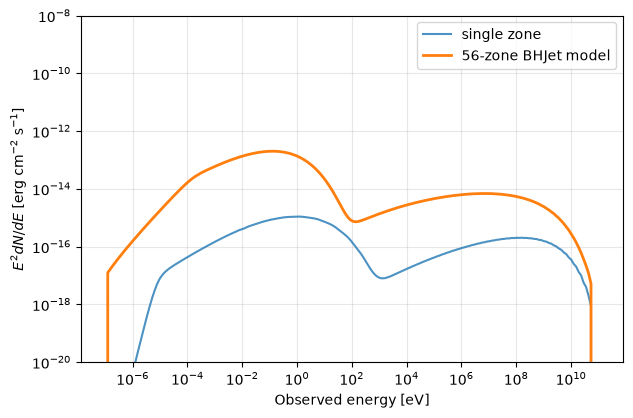

In [61]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(single_zone_energy_eV, single_zone_sed, label='single zone', alpha=0.8)
ax.loglog(energy_eV, multi_zone_sed,
          label=f'{dynamics.n_zones}-zone BHJet model', lw=2)
ax.set(xlabel='Observed energy [eV]', ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.grid(alpha=0.3)
ax.legend()
plt.ylim(1e-20, 1e-8)
plt.show()

## 6. Compare BHJet to the observed SED

This is a by-hand exploration of the parameter space. In the cell below, we have left typical free parameters that we modify when studying SEDs. First change one of the marked parameters below, then plot. 

In [62]:
FIT_PARAMETERS = MULTI_ZONE_PARAMETERS.copy()
FIT_PARAMETERS.update({
    'jet_power_eddington': 2e-3,
    'z_dissipation': 100.0,
    'electron_temperature_jet_base': 500.0,
    'factor_max_energy_electrons': 8e-9,
    'index_injected_electrons': 1.75,
    'z_end_of_acceleration': 1e4
})

fit_dynamics, fit_jet, fit_sed = calculate_multi_zone_sed(FIT_PARAMETERS)

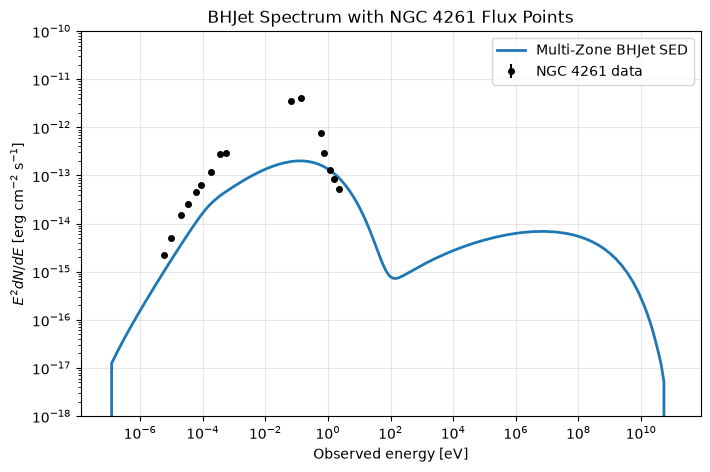

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_energy.to_value(u.eV), data_sed.value, yerr=data_sed_error.value, fmt='o', ms=4,
            color='black', label=f'{SOURCE_NAME} data')

ax.loglog(energy_eV, multi_zone_sed, lw=2, label='Multi-Zone BHJet SED')
ax.set(xlabel='Observed energy [eV]', ylabel=r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet Spectrum with {SOURCE_NAME} Flux Points')
ax.set_ylim(1e-18, 1e-10)
ax.grid(alpha=0.3)
ax.legend();

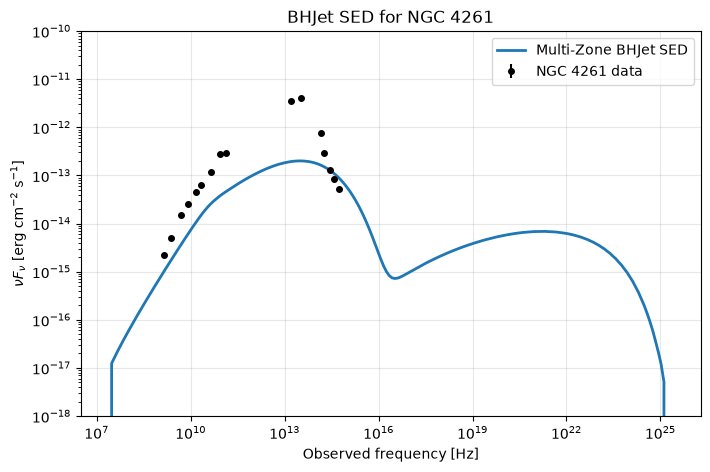

In [ ]:
data_frequency_hz = data_energy.to_value(u.Hz, equivalencies=u.spectral())
fit_frequency_hz = (energy_eV * u.eV).to_value(u.Hz, equivalencies=u.spectral())

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(data_frequency_hz, data_sed.value, yerr=data_sed_error.value,
            fmt='o', ms=4, color='black', label=f'{SOURCE_NAME} data')

ax.loglog(fit_frequency_hz, multi_zone_sed, lw=2, label='Multi-Zone BHJet SED')
ax.set(xscale='log', yscale='log', xlabel='Observed frequency [Hz]',
       ylabel=r'$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]',
       title=f'BHJet SED for {SOURCE_NAME}')
ax.grid(alpha=0.3)
ax.set_ylim(1e-18, 1e-10)
ax.legend();